In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
DIR = "Datasets For Testing/Advertising.csv"
df = pd.read_csv(DIR).drop("ID", axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<Axes: xlabel='newspaper', ylabel='sales'>

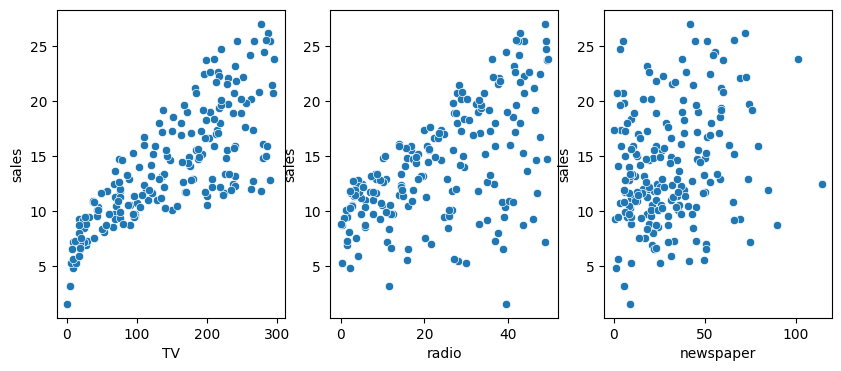

In [3]:
fig, axis = plt.subplots(1,3,figsize=(10,4))

sns.scatterplot(x=df["TV"], y= df["sales"],ax=axis[0])
sns.scatterplot(x=df["radio"], y= df["sales"], ax=axis[1])
sns.scatterplot(x=df["newspaper"], y= df["sales"], ax=axis[2])

In [4]:
X = df.drop("sales", axis=1)
y = df["sales"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from simpleml.pipeline import make_pipeline
from simpleml.Preprocessing import ZScoreScaler
from simpleml.linear_models import SGDRegressor

pipe = make_pipeline(
    ZScoreScaler(),
    SGDRegressor(random_state=42, early_stopping=False)
    )
pipe.fit(X_train, y_train)

Val Loss: 2.7052337786151077


In [11]:
reg = pipe.named_steps["sgdregressor"]

In [12]:
y_pred = pipe.predict(X_test)

In [13]:
from simpleml.metrics import regression_report
print("With L2 Regularization: ", regression_report(y_test, y_pred))

With L2 Regularization:  {'R2 Score': 0.898955, 'Mean Squared Error': 3.189344, 'Mean Absolute Error': 1.463874, 'Root Mean Squared Error': 1.785873, 'Mean Absolute Percentage Error': 15.201039}


In [14]:
reg.coef_

array([3.74804989, 2.77653946, 0.06325646])

In [20]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

model = make_pipeline(StandardScaler(), SGDRegressor(early_stopping=True, random_state=42))
regsk = model.fit(X_train, y_train)


In [21]:
y_pred = regsk.predict(X_test)
r2_score(y_test,y_pred)

0.9014258593003728